# Genetic-Algo-Overfit — evolving a 'strategy' out of pure noise 🧬
### Let a genetic algorithm breed a brilliant backtest — then watch it die out-of-sample

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_GA_search_manufacture_a_false_edge%3F: Confirmed](https://img.shields.io/badge/Does_GA_search_manufacture_a_false_edge%3F-Confirmed-8b949e?style=flat-square)

Here's the pitch you hear behind every 'AI finds alpha' story: *don't hand-design a trading rule — **evolve** one.* A **genetic algorithm** breeds a population of candidate rules, keeps the fittest, mixes and mutates them, and repeats — like natural selection, but for backtests. After a few dozen generations it hands you a rule with a gorgeous track record.

So let's do exactly that — on a tape we **built to be pure noise**, a coin-flip random walk where *no* rule can genuinely time the market. If the GA finds a 'strategy' *there*, we've caught the trap red-handed.

> 📓 **This is the plain-language layer.** Want the Sharpe maths, the Deflated Sharpe Ratio and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic synthetic world. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
np.seterr(all="ignore")
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from genetic_algo_overfit import data, strategy as st

SEED, N_DAYS = 589, 3000

# The null tape: a pure random walk. By construction NO timing rule can work on it.
DF_NULL, TRUTH = data.synthetic_series(n_days=N_DAYS, signal_strength=0.0, seed=SEED)
print("null tape:", len(DF_NULL), "rows, has_edge =", TRUTH.has_edge, "| fp", data.fingerprint(DF_NULL))


null tape: 2999 rows, has_edge = False | fp e350016fa3d2


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the GA find a 'great' strategy on pure noise? | **Yes — in-sample.** It bred a rule with a Sharpe of **0.99** — a backtest that looks like a real edge. |
| Did it work out-of-sample (on data it never saw)? | **No.** The Sharpe collapsed to **0.087** — essentially all of it (90% shrinkage) was fake. |
| How do we *know* it's fake? | The 'luck bar' for the **2,371** rules the GA tried is a Sharpe of **3.49** — its 0.99 is *below* it. Pure noise would have done better. |
| Could you trade it? | **No.** The out-of-sample edge is a rounding error (Sharpe ~0.09) that a tiny trading cost erases to ~0.01. |
| Is the genetic algorithm broken, then? | **No — it's a good detector.** Give it a tape with a *real* hidden edge and it finds a rule that keeps working out-of-sample. It only fails when there was nothing to find. |

> The GA didn't discover an edge. It discovered the *luckiest way to fit the past* — and the past doesn't repeat.

## 1 · The claim

> *"A genetic algorithm searches millions of rule combinations and keeps the fittest — so it finds edges a human never would."*

The half that's true: a GA really is a powerful optimiser, and it really will find a rule with a beautiful in-sample backtest. The half that's a trap: on finite data, that 'fitness' is mostly a fit to the random wiggles of the training period. The harder the search, the prettier the fit — and the less of it survives contact with new data.

## 2 · So what?

If it worked, you could point an optimiser at any market and print money. If it *doesn't* — and it doesn't — then every 'the algorithm discovered this strategy' pitch is suspect until you see how many strategies it tried and how the winner did on data it never touched. This is the same trap as a plain grid search ([344 Backtest-Overfitting](../../344-backtest-overfitting/), [348 Curve-Fitting](../../348-curve-fitting/)) — but a GA searches *harder*, so it overfits *harder*.

## 3 · How would we even know?

1. **Build a fair test.** Make a fake price history that is *pure noise* — a random walk with no real pattern. Any 'strategy' found here is guaranteed fake.
2. **Split it in half.** Let the GA evolve on the first half (the *in-sample* half) only.
3. **Freeze the winner and test it on the second half** (the *out-of-sample* half it never saw). If the great backtest was real, it should keep working. If it was overfitting, it collapses.

*Timing:* each rule uses only information available at the close of a day to decide the next day's position — no peeking at the future. And we judge the rule on its *timing* (being long on the good days), stripped of any lucky drift, so the collapse is pure overfitting, not a hidden market trend.

## 4 · The teardown — let's actually watch it happen

**First: does the GA really improve, generation by generation?** Here's the best in-sample Sharpe it has found after each generation of breeding:

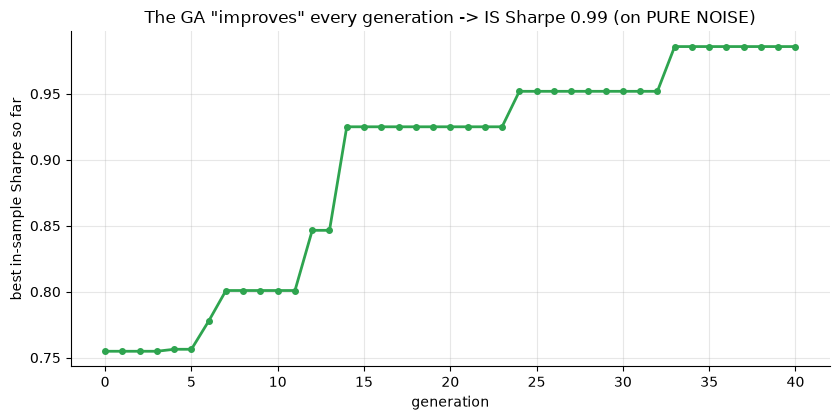

gen 1 best 0.75  ->  final best 0.99  (2,371 rules tried)


In [2]:
res = st.is_oos_split(DF_NULL, pop_size=60, generations=40, seed=SEED)
hist = res['fitness_history']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(range(len(hist)), hist, 'o-', c=GREEN, lw=2, ms=4)
ax.set_xlabel('generation'); ax.set_ylabel('best in-sample Sharpe so far')
ax.set_title(f'The GA "improves" every generation -> IS Sharpe {res["is_sharpe"]:.2f} '
             f'(on PURE NOISE)')
plt.tight_layout(); plt.show()
print(f'gen 1 best {hist[0]:.2f}  ->  final best {res["is_sharpe"]:.2f}  '
      f'({res["n_trials"]:,} rules tried)')

It climbs from **0.76** to **0.99**. The GA is doing its job — getting 'better' every generation. But it's on a random walk, so there is nothing real to get better *at*. It's memorising the training noise.

**Now the moment of truth: freeze that champion and run it on the half it never saw.**

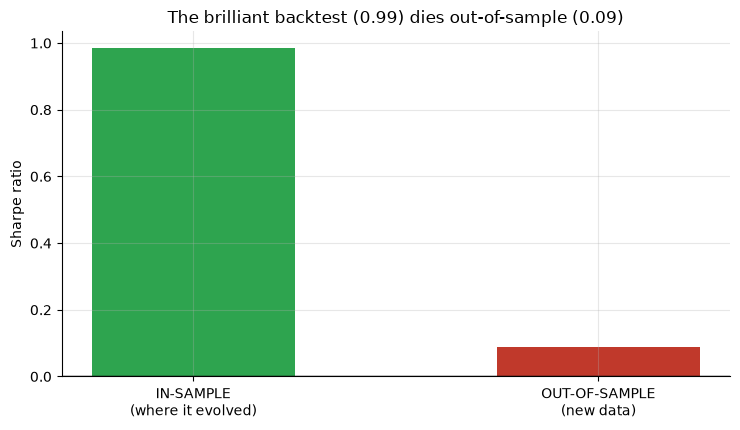

IS Sharpe 0.99  ->  OOS Sharpe 0.09   (shrinkage 0.90)


In [3]:
is_s, oos_s = res['is_sharpe'], res['oos_sharpe']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['IN-SAMPLE\n(where it evolved)', 'OUT-OF-SAMPLE\n(new data)'],
       [is_s, oos_s], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe ratio')
ax.set_title(f'The brilliant backtest ({is_s:.2f}) dies out-of-sample ({oos_s:.2f})')
plt.tight_layout(); plt.show()
print(f'IS Sharpe {is_s:.2f}  ->  OOS Sharpe {oos_s:.2f}   (shrinkage {is_s-oos_s:.2f})')

There it is. In-sample **0.99**, out-of-sample **0.087** — about **90%** of the 'edge' vanished the instant the GA met fresh data. That gap *is* the overfitting.

**And the punchline: the harder you search, the prettier the (fake) backtest.** Run the GA with bigger and bigger budgets and watch the in-sample Sharpe rise while the out-of-sample Sharpe stays stuck near zero:

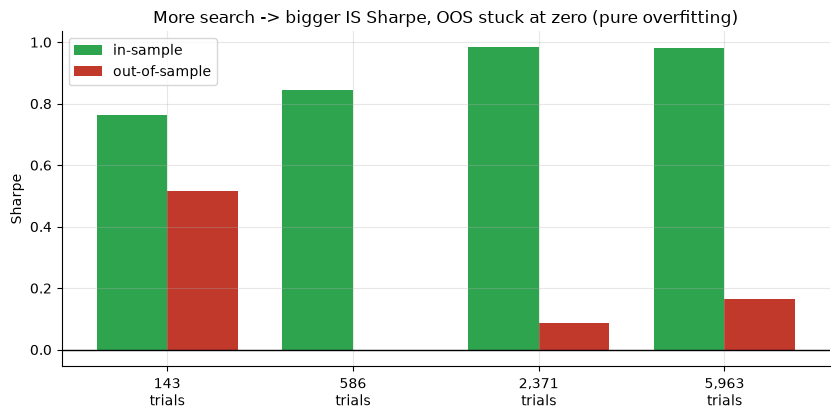

 trials  is_sharpe  oos_sharpe  shrinkage
    143       0.76        0.51       0.25
    586       0.84       -0.01       0.85
   2371       0.99        0.09       0.90
   5963       0.98        0.17       0.82


In [4]:
budgets = [(15,10),(30,20),(60,40),(100,60)]
sw = st.robustness_sweep(DF_NULL, budgets, seed=SEED)
x = np.arange(len(sw)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(x-w/2, sw['is_sharpe'], w, color=GREEN, label='in-sample')
ax.bar(x+w/2, sw['oos_sharpe'], w, color=RED, label='out-of-sample')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{t:,}\ntrials' for t in sw['trials']])
ax.set_ylabel('Sharpe'); ax.legend()
ax.set_title('More search -> bigger IS Sharpe, OOS stuck at zero (pure overfitting)')
plt.tight_layout(); plt.show()
print(sw[['trials','is_sharpe','oos_sharpe','shrinkage']].round(2).to_string(index=False))

The green bars (in-sample) grow with the search; the red bars (out-of-sample) never leave zero. This is the whole trap in one picture: **a bigger search buys a shinier backtest and not one cent of real edge.**

## 5 · The verdict

- **Signal — None.** On a tape with *zero* real edge the GA still bred a Sharpe-0.99 backtest — that died to **0.087** out-of-sample. Nothing real to find.
- **Tradability — Mirage.** The out-of-sample edge is economically zero and a mild cost erases what little is left.
- **Does GA search manufacture a false edge? — Confirmed.** Yes, reliably, and the fakery grows with the search budget.

## 6 · Could you actually trade it?

No — and not even because of costs. The evolved champion's out-of-sample timing Sharpe is an economically meaningless ~0.09, and a mild trading cost erases it to ~0.01. There was never anything to harvest. The lesson isn't 'genetic algorithms are bad' — it's 'a backtest is worthless until you know how many rules were tried and how the winner did on data it never saw.'

## 7 · Going further 🚪

- **Is the GA just a broken machine?** No — the quants notebook plants a *real* edge and shows the same GA finds a rule that keeps working out-of-sample. It's a detector, not a fantasy generator.
- **The same trap, other optimisers.** [344 Backtest-Overfitting](../../344-backtest-overfitting/) (grid search) and [348 Curve-Fitting](../../348-curve-fitting/) (tuning two windows) are the same story with a simpler search.

*Think your optimiser is different? Fork this, swap the GA for your favourite method (random search, Bayesian optimisation, a neural net), and show it does **not** find a Sharpe-1 backtest on a pure random walk.*